[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/01_unidad/01_02_EDA_Basic_Example.ipynb)


# Fundamentos de Analítica I
# Ejemplo de Análisis Exploratorio de Datos en Python


El dataset que vamos analizar contiene registros de pacientes con síntomas de problemas cardíacos.
Se tiene una base de datos de enfermedades del corazón, provenientes de diferentes centros médicos:
- Cleveland Clinic Foundation
- Hungarian Institute of Cardiology, Budapest
- University Hospital, Zurich, & University Hospital, Basel, Switzerland 

Los campos del dataset son los siguientes:
1. ciudad: ciudad del paciente (Cleveland, Hungria, Suiza)
2. edad: en años
3. sexo: "1"=hombre, "0"=mujer
4. tipo_dolor: tipo de dolor de pecho ("1"=angina típico, "2"=angina atípico, "3"=dolor no de angina, "4"=sin síntoma de dolor)
5. presion: presión de la sangre en reposo (en mm/Hg, en el momento de admisión al hospital)
6. colesterol: en densidad del colesterol (en mg/dl)
7. azucar: indica si el nivel de azucar en la sangre en ayunas es superior a 120 mg/dl ("1") o no ("0")
8. ecg: resultado el electro cardiograma ("0"=normal, "1"=anormalidad del nivel de ST, "2"=hipertrofía ventricular probable)
9. pulso: frecuencia cardiaca máxima alcanzada
10. angina: si se induce a una angina a través del ejercicio ("1") o no ("0")
11. st: diferencia relativa entre el nivel de ST inducido por el ejercicio comparado con el nivel del reposo.
12. pendiente: la pendiente de llegada al máximo del nivel ST durante el ejercicio ("1"creciente, "2"=plana, "3"=decreciente)
13. venas: número de venas coloreadas a partir de la fluorescopia (0 a 3)
14. thal: tipo de defecto (valores aceptados 3=normal, 4=defecto arreglado, 7=defecto reversible)
15. target: indica si en efecto el paciente presenta una enfermedad cardiaca ("1", "2", "3", "4") o no ("0")

# Entendimiento de los datos, limpieza

El archivo DatosCorazon contiene el dataset que a analizar.

Vamos a realizar un análisis exploratorio de los datos estableciendo el baseline, verificando la calidad de los datos (tipos de las variables, valores inválidos, excepciones, valores faltantes, etc.), utilizando gráficos para poder entender las distribuciones de los datos e identificar posibles problemas.

# 1 Carga, baseline y pre-limpieza de datos

In [1]:
import pandas as pd #tratamiento de datos
import numpy as np #operaciones matriciales y con vectores
import matplotlib.pyplot as plt #gráficos
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Cargamos los datos en memoria y visualizamos los datos iniciales y resumidos.

In [2]:
url = "https://raw.githubusercontent.com/leoe21/machine_learning_fundamentals/refs/heads/main/01_unidad/01_02_Dataset_DatosCorazon.csv"
data = pd.read_csv(url, sep=";", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Cleveland,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,Cleveland,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2
2,Cleveland,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,Cleveland,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,Cleveland,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


Los campos no vienen con los datos, por lo que los especificamos directamente

In [3]:
colnames = ["ciudad", "edad", "sexo", "tipo_dolor", "presion", "colesterol", "azucar", "ecg", "pulso", "angina", 
         "st", "pendiente", "venas", "thal", "target"]
data.columns=colnames
data.head()

,ciudad,edad,sexo,tipo_dolor,presion,colesterol,azucar,ecg,pulso,angina,st,pendiente,venas,thal,target
0,Cleveland,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,Cleveland,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2
2,Cleveland,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,Cleveland,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,Cleveland,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


Vamos a arreglar la variable categórica. Primero establecemos los 2 valores posibles.
Modificamos reemplazando los 4 valores que se considerarán como positivos.

[Text(0, 0, '360'),
 Text(0, 0, '209'),
 Text(0, 0, '68'),
 Text(0, 0, '65'),
 Text(0, 0, '18')]

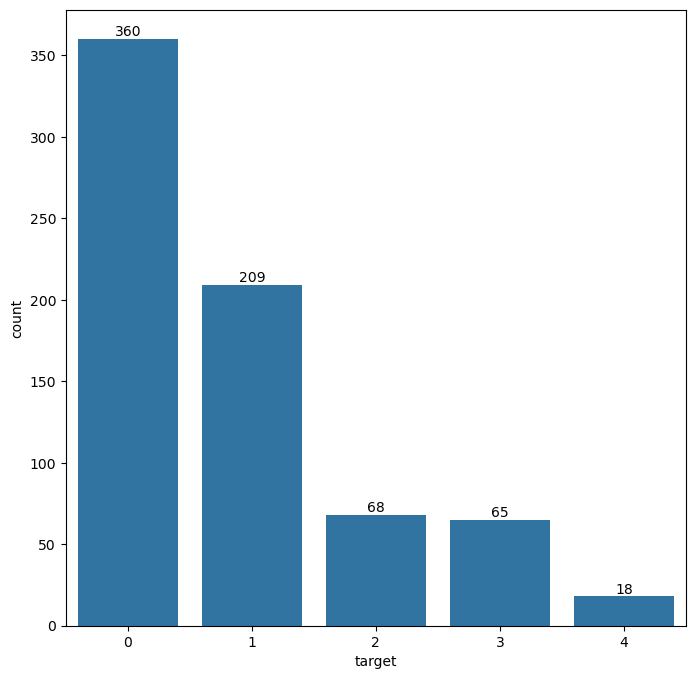

In [4]:
plt.figure(figsize=(8,8))
ax = sns.countplot(x="target", data=data)
ax.bar_label(ax.containers[0])

Vamos a ver la cantidad de observaciones por categoría de la variable objetivo

In [4]:
pd.crosstab(index=data["target"], columns="count")

col_0,count
target,
0,360
1,209
2,68
3,65
4,18


Vamos a convertir todas aquellas observaciones con variable objetivo positiva como 1

In [5]:
data.loc[(data.target > 0), "target"] = 1

### Baseline global

[Text(0, 0, '360'), Text(0, 0, '360')]

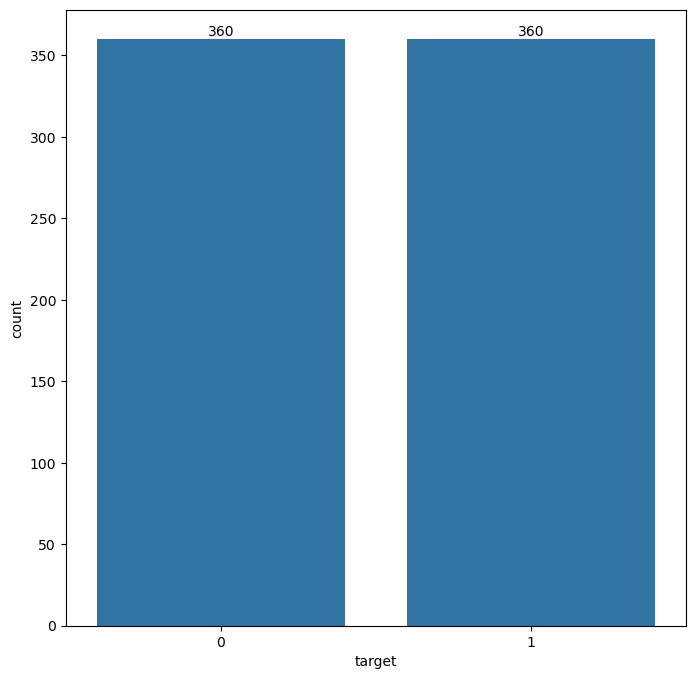

In [6]:
plt.figure(figsize=(8,8))
ax = sns.countplot(x="target", data=data)
ax.bar_label(ax.containers[0])

La variable objetivo debería ser categórica, por tal razón hacemos la conversión

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      720 non-null    object 
 1   edad        720 non-null    float64
 2   sexo        720 non-null    int64  
 3   tipo_dolor  720 non-null    int64  
 4   presion     720 non-null    object 
 5   colesterol  720 non-null    object 
 6   azucar      720 non-null    object 
 7   ecg         720 non-null    object 
 8   pulso       720 non-null    object 
 9   angina      720 non-null    object 
 10  st          720 non-null    object 
 11  pendiente   720 non-null    object 
 12  venas       720 non-null    object 
 13  thal        720 non-null    object 
 14  target      720 non-null    int64  
dtypes: float64(1), int64(3), object(11)
memory usage: 84.5+ KB


In [7]:
data.target = data.target.astype(str)

In [10]:
pd.crosstab(index=data["target"], columns="count")

col_0,count
target,
0,360
1,360


In [8]:
data.shape

(720, 15)

In [9]:
data['target'][data['target'] == '0'].count()/data.shape[0]*100

50.0

Observamos que el baseline global es de 50%, con las dos clases igualmente representadas en perfecto balance.

### Baseline por ciudad

[Text(0, 0, '303'), Text(0, 0, '294'), Text(0, 0, '123')]

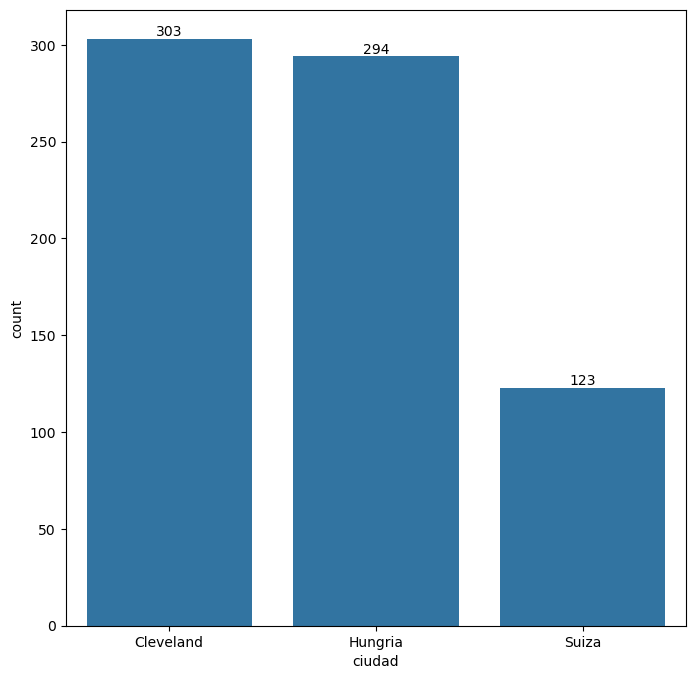

In [10]:
plt.figure(figsize=(8,8))
ax = sns.countplot(x='ciudad', data=data)
ax.bar_label(ax.containers[0])

In [11]:
pd.crosstab(index=data['ciudad'],columns='count')

col_0,count
ciudad,
Cleveland,303
Hungria,294
Suiza,123


Vemos que la mayoría de los datos son de Cleveland

In [12]:
dataCleveland=data[data.ciudad=="Cleveland"]
dataHungria=data[data.ciudad=="Hungria"]
dataSuiza=data[data.ciudad=="Suiza"]

### Baseline Cleveland

[Text(0, 0, '164'), Text(0, 0, '139')]

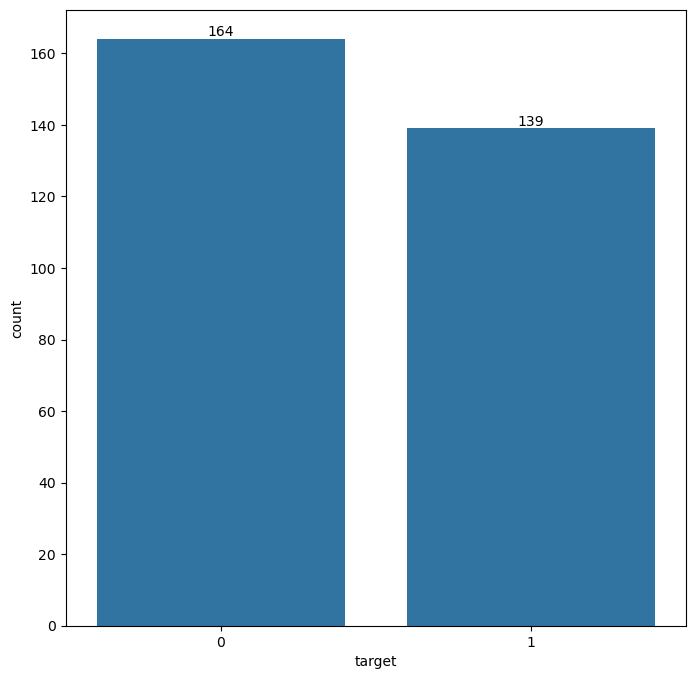

In [13]:
plt.figure(figsize=(8,8))
ax = sns.countplot(x='target', data=dataCleveland)
ax.bar_label(ax.containers[0])

In [14]:
dataCleveland['target'][dataCleveland['target'] == '0'].count()/dataCleveland.shape[0]*100

54.12541254125413

Podemos observar que el 54% de las personas que viven en Cleveland no tienen problemas del corazón

### Baseline Suiza

[Text(0, 0, '115'), Text(0, 0, '8')]

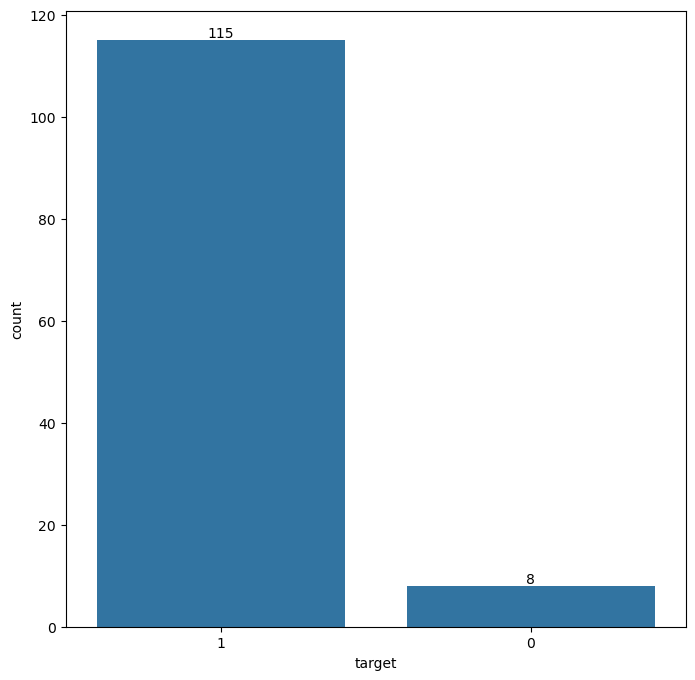

In [15]:
plt.figure(figsize=(8,8))
ax =sns.countplot(x='target',data=dataSuiza)
ax.bar_label(ax.containers[0])

In [20]:
dataSuiza[dataSuiza['target'] == '1']['target'].count()/dataSuiza.shape[0]*100

93.4959349593496

El baseline de Suiza es que la gente tiene problemas cardíacos en un 93.5%

### Baseline Hungría

[Text(0, 0, '188'), Text(0, 0, '106')]

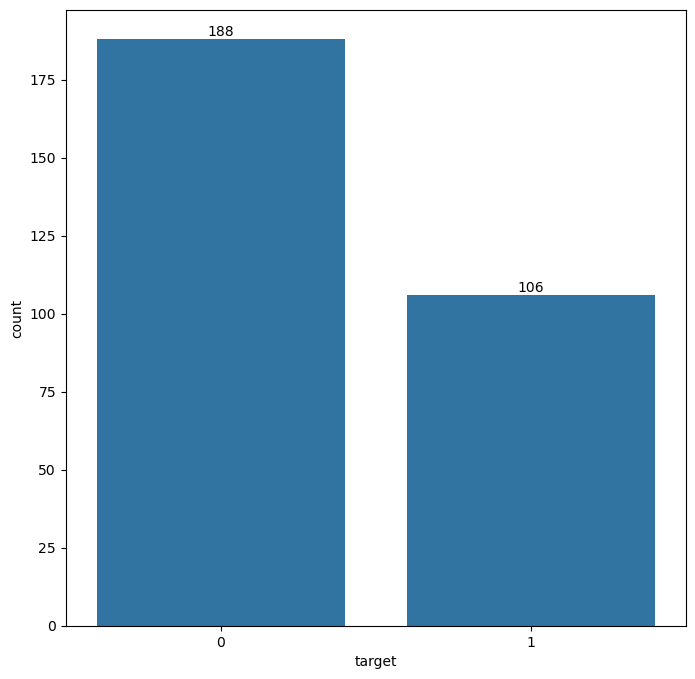

In [16]:
plt.figure(figsize=(8,8))
ax=sns.countplot(x='target',data=dataHungria)
ax.bar_label(ax.containers[0])

In [22]:
dataHungria[dataHungria['target'] == '0']['target'].count()/dataHungria.shape[0]*100

63.94557823129252

El Baseline para Hungría es  un 63.95%

Los datasets son bastante diferentes y de pronto no sería bueno utilizarlos conjuntamente. No resulta prudente para diagnosticar un paciente de Cleveland utilizar un modelo aprendido con los tres conjuntos de datos, pues sus niveles de desbalanceo son muy diferentes. La clase positiva tiene una proporción de 50% para Cleveland, 93.5% para Suiza y de 36.05% para Hungría.

## 2. Análisis de los problemas de calidad de los datos

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      720 non-null    object 
 1   edad        720 non-null    float64
 2   sexo        720 non-null    int64  
 3   tipo_dolor  720 non-null    int64  
 4   presion     720 non-null    object 
 5   colesterol  720 non-null    object 
 6   azucar      720 non-null    object 
 7   ecg         720 non-null    object 
 8   pulso       720 non-null    object 
 9   angina      720 non-null    object 
 10  st          720 non-null    object 
 11  pendiente   720 non-null    object 
 12  venas       720 non-null    object 
 13  thal        720 non-null    object 
 14  target      720 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 84.5+ KB


Aquí podemos ver que:
- hay tipos de datos que no corresponden a los del diccionario
- aparentemente no hay valores faltantes

In [18]:
data.describe(include='all')

,ciudad,edad,sexo,tipo_dolor,presion,colesterol,azucar,ecg,pulso,angina,st,pendiente,venas,thal,target
count,720,720.000000,720.000000,720.000000,720,720,720,720,720,720,720,720,720,720,720
unique,3,NaN,NaN,NaN,86,307,3,4,188,3,61,6,6,6,2
top,Cleveland,NaN,NaN,NaN,120,0,0,0,150,0,0,2,?,?,0
freq,303,NaN,NaN,NaN,78,123,567,471,32,476,330,290,413,320,360
mean,NaN,51.888889,0.738889,3.179167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,9.193720,0.439546,0.953646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,28.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,45.000000,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,53.000000,1.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,58.000000,1.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Aquí podemos ver que:
- confirmamos los tipos de variables que no corresponden para bastantes de las columnas.
- encontramos en las variables venas y thal datos categóricos donde el valor más común es "?", este problema podría aparecer en otras variables categóricas donde "?" no es el valor más preponderante.
- el número de valores posibles no corresponde para las variables: 
  - azucar (3 en vez de 2) 
  - ecg (4 en vez de 3)
  - angina (3 en vez de 2)
  - pendiente (6 en vez de 3)
  - venas (6 en vez de 4)
  - thal (6 en vez de 3)

In [25]:
data.dtypes

ciudad         object
edad          float64
sexo            int64
tipo_dolor      int64
presion        object
colesterol     object
azucar         object
ecg            object
pulso          object
angina         object
st             object
pendiente      object
venas          object
thal           object
target         object
dtype: object

### Limpieza: valores inválidos y tipos de columnas
Varias de los atributos del dataset fueron leidos con el tipo de datos que no correspondía:
- "sexo" es una variable categórica codificada con valores "0" y "1"
- "tipo_dolor" es una variable categórica codificada con valores "1", "2", "3", y "4"
- "presion" es una variable numérica que aparece como categórica
- "colesterol" es una variable numérica que aparece como categórica
- "pulso": es una variable numérica que aparece como categórica
- "st": es una variable numérica que aparece como categórica

Primero convertimos las variables numéricas incorrectas a categóricas

In [26]:
cols = ['sexo','tipo_dolor']
for col in cols:
    data[col] = data[col].astype(str)

Verificamos que variables categóricas tienen valores de ?

In [27]:
for var in data.select_dtypes(include=['object']).columns:
    cantidad = data[data[var] == '?'][var].count()
    print(f"Existen {cantidad} valores en {var} con el valor ?")

Existen 0 valores en ciudad con el valor ?
Existen 0 valores en sexo con el valor ?
Existen 0 valores en tipo_dolor con el valor ?
Existen 3 valores en presion con el valor ?
Existen 23 valores en colesterol con el valor ?
Existen 83 valores en azucar con el valor ?
Existen 2 valores en ecg con el valor ?
Existen 2 valores en pulso con el valor ?
Existen 2 valores en angina con el valor ?
Existen 6 valores en st con el valor ?
Existen 207 valores en pendiente con el valor ?
Existen 413 valores en venas con el valor ?
Existen 320 valores en thal con el valor ?
Existen 0 valores en target con el valor ?


No podemos convertir en numéricos algunos de los campos presion, colesterol, pulso y st, ya que se encuentra el caracter "?", que no se puede convertir a número.
Suponemos que este caracter indica un valor faltante, por lo que convertimos todos los valores correspondientes a nan.

In [28]:
data = data.replace('?',np.nan)

Habiendo realizado estos cambios ya podemos convertir las variables categóricas incorrectas en numéricas

In [29]:
columns = ['presion','colesterol','pulso','st']
for col in columns:
    data[col] = data[col].astype('float64')

Revisamos los nuevos tipos de datos para todas las variables del dataset

In [30]:
data.describe(include='all')

,ciudad,edad,sexo,tipo_dolor,presion,colesterol,azucar,ecg,pulso,angina,st,pendiente,venas,thal,target
count,720,720.000000,720,720,717.000000,697.000000,637,718,718.000000,718,714.000000,513,307,400,720
unique,3,NaN,2,4,NaN,NaN,2,3,NaN,2,NaN,5,5,5,2
top,Cleveland,NaN,1,4,NaN,NaN,0,0,NaN,0,NaN,2,0,3,0
freq,303,NaN,532,365,NaN,NaN,567,471,NaN,476,NaN,290,177,190,360
mean,NaN,51.888889,NaN,NaN,131.804742,204.774749,NaN,NaN,140.565460,NaN,0.789636,NaN,NaN,NaN,NaN
std,NaN,9.193720,NaN,NaN,18.529331,109.275156,NaN,NaN,25.647172,NaN,1.066961,NaN,NaN,NaN,NaN
min,NaN,28.000000,NaN,NaN,80.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN,NaN,NaN
25%,NaN,45.000000,NaN,NaN,120.000000,182.000000,NaN,NaN,122.000000,NaN,0.000000,NaN,NaN,NaN,NaN
50%,NaN,53.000000,NaN,NaN,130.000000,227.000000,NaN,NaN,142.000000,NaN,0.200000,NaN,NaN,NaN,NaN
75%,NaN,58.000000,NaN,NaN,140.000000,270.000000,NaN,NaN,160.000000,NaN,1.500000,NaN,NaN,NaN,NaN


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      720 non-null    object 
 1   edad        720 non-null    float64
 2   sexo        720 non-null    object 
 3   tipo_dolor  720 non-null    object 
 4   presion     717 non-null    float64
 5   colesterol  697 non-null    float64
 6   azucar      637 non-null    object 
 7   ecg         718 non-null    object 
 8   pulso       718 non-null    float64
 9   angina      718 non-null    object 
 10  st          714 non-null    float64
 11  pendiente   513 non-null    object 
 12  venas       307 non-null    object 
 13  thal        400 non-null    object 
 14  target      720 non-null    object 
dtypes: float64(5), object(10)
memory usage: 84.5+ KB


### Limpieza: valores faltantes
Varios de los atributos del dataset presentan valores faltantes
- "presion" tiene 3 registros sin valor
- "colesterol" tiene 23 registros sin valor
- "azucar" tiene 83 registros sin valor
- "ecg" tiene 2 registros sin valor
- "pulso" tiene 2 registros sin valor
- "angina" tiene 2 registros sin valor
- "st" tiene 6 registros sin valor
- "pendiente" tiene 207 registros sin valor
- "venas" tiene 413 registros sin valor
- "thal" tiene 320 registros sin valor

Vamos a tratar de encontrar patrones en los valores faltantes. Primero analizamos los registros con pocos valores faltantes. Empezamos con la presión

In [32]:
data[data['presion'].isna()]

,ciudad,edad,sexo,tipo_dolor,presion,colesterol,azucar,ecg,pulso,angina,st,pendiente,venas,thal,target
393,Hungria,48.0,0,2,NaN,308.0,0,1,NaN,NaN,2.0,1,NaN,NaN,0
599,Suiza,35.0,1,4,NaN,0.0,NaN,0,130.0,1,NaN,NaN,NaN,7,1
714,Suiza,69.0,1,4,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,7,1


Vemos que los 3 registros de presion con NAs (393, 599, 714). Son los 2 de pulso, los 2 de angina, 2 de los 6 de st. Vamos a eliminarlos. Vemos además que estos registros corresponden a 2 de las ciudades, por lo que no hay un patrón con respecto a la provenencia de los registros faltantes.

In [33]:
data = data[~data['presion'].isna()]

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 717 entries, 0 to 719
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      717 non-null    object 
 1   edad        717 non-null    float64
 2   sexo        717 non-null    object 
 3   tipo_dolor  717 non-null    object 
 4   presion     717 non-null    float64
 5   colesterol  694 non-null    float64
 6   azucar      635 non-null    object 
 7   ecg         715 non-null    object 
 8   pulso       717 non-null    float64
 9   angina      717 non-null    object 
 10  st          713 non-null    float64
 11  pendiente   512 non-null    object 
 12  venas       307 non-null    object 
 13  thal        398 non-null    object 
 14  target      717 non-null    object 
dtypes: float64(5), object(10)
memory usage: 89.6+ KB


Continuamos con los valores faltantes de ecg y st

In [35]:
data[data['ecg'].isna()]

,ciudad,edad,sexo,tipo_dolor,presion,colesterol,azucar,ecg,pulso,angina,st,pendiente,venas,thal,target
571,Hungria,55.0,1,1,140.0,295.0,0,NaN,136.0,0,0.0,NaN,NaN,NaN,1
598,Suiza,34.0,1,4,115.0,0.0,NaN,NaN,154.0,0,0.2,1,NaN,NaN,1


In [36]:
data[data['st'].isna()]

,ciudad,edad,sexo,tipo_dolor,presion,colesterol,azucar,ecg,pulso,angina,st,pendiente,venas,thal,target
606,Suiza,38.0,1,4,150.0,0.0,NaN,0,120.0,1,NaN,NaN,NaN,3,1
636,Suiza,52.0,1,4,95.0,0.0,NaN,0,82.0,1,NaN,NaN,NaN,NaN,1
705,Suiza,65.0,1,4,145.0,0.0,NaN,1,67.0,0,NaN,NaN,NaN,6,1
707,Suiza,65.0,1,4,160.0,0.0,1,1,122.0,0,NaN,NaN,NaN,7,1


Son registros diferentes, la mayoria de ellos provenientes de Suiza. Los vamos a eliminar

In [37]:
data = data[~data['ecg'].isna()]

In [38]:
data = data[~data['st'].isna()]

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 0 to 719
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      711 non-null    object 
 1   edad        711 non-null    float64
 2   sexo        711 non-null    object 
 3   tipo_dolor  711 non-null    object 
 4   presion     711 non-null    float64
 5   colesterol  688 non-null    float64
 6   azucar      633 non-null    object 
 7   ecg         711 non-null    object 
 8   pulso       711 non-null    float64
 9   angina      711 non-null    object 
 10  st          711 non-null    float64
 11  pendiente   511 non-null    object 
 12  venas       307 non-null    object 
 13  thal        395 non-null    object 
 14  target      711 non-null    object 
dtypes: float64(5), object(10)
memory usage: 88.9+ KB


Las variables venas, pendiente y thal tienen demasiados valores faltantes, por lo cual las vamos a eliminar

In [41]:
data.drop(columns=['venas','pendiente','thal'],inplace=True)

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 0 to 719
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      711 non-null    object 
 1   edad        711 non-null    float64
 2   sexo        711 non-null    object 
 3   tipo_dolor  711 non-null    object 
 4   presion     711 non-null    float64
 5   colesterol  688 non-null    float64
 6   azucar      633 non-null    object 
 7   ecg         711 non-null    object 
 8   pulso       711 non-null    float64
 9   angina      711 non-null    object 
 10  st          711 non-null    float64
 11  target      711 non-null    object 
dtypes: float64(5), object(7)
memory usage: 72.2+ KB


Vamos a modificar azucar, creando una nueva categoría para los valores faltantes

In [43]:
pd.crosstab(index=data['azucar'],columns='count')

col_0,count
azucar,
0,564
1,69


In [44]:
data.loc[data['azucar'].isna(),'azucar'] = -1

In [45]:
pd.crosstab(index=data['azucar'],columns='count')

col_0,count
azucar,
-1,78
0,564
1,69


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 0 to 719
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      711 non-null    object 
 1   edad        711 non-null    float64
 2   sexo        711 non-null    object 
 3   tipo_dolor  711 non-null    object 
 4   presion     711 non-null    float64
 5   colesterol  688 non-null    float64
 6   azucar      711 non-null    object 
 7   ecg         711 non-null    object 
 8   pulso       711 non-null    float64
 9   angina      711 non-null    object 
 10  st          711 non-null    float64
 11  target      711 non-null    object 
dtypes: float64(5), object(7)
memory usage: 72.2+ KB


Vamos a reemplazar los valores faltantes de colesterol por el promedio

In [47]:
data.loc[data['colesterol'].isna(),'colesterol'] = data['colesterol'].mean()

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 0 to 719
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ciudad      711 non-null    object 
 1   edad        711 non-null    float64
 2   sexo        711 non-null    object 
 3   tipo_dolor  711 non-null    object 
 4   presion     711 non-null    float64
 5   colesterol  711 non-null    float64
 6   azucar      711 non-null    object 
 7   ecg         711 non-null    object 
 8   pulso       711 non-null    float64
 9   angina      711 non-null    object 
 10  st          711 non-null    float64
 11  target      711 non-null    object 
dtypes: float64(5), object(7)
memory usage: 72.2+ KB


### Limpieza Búsqueda de excepciones

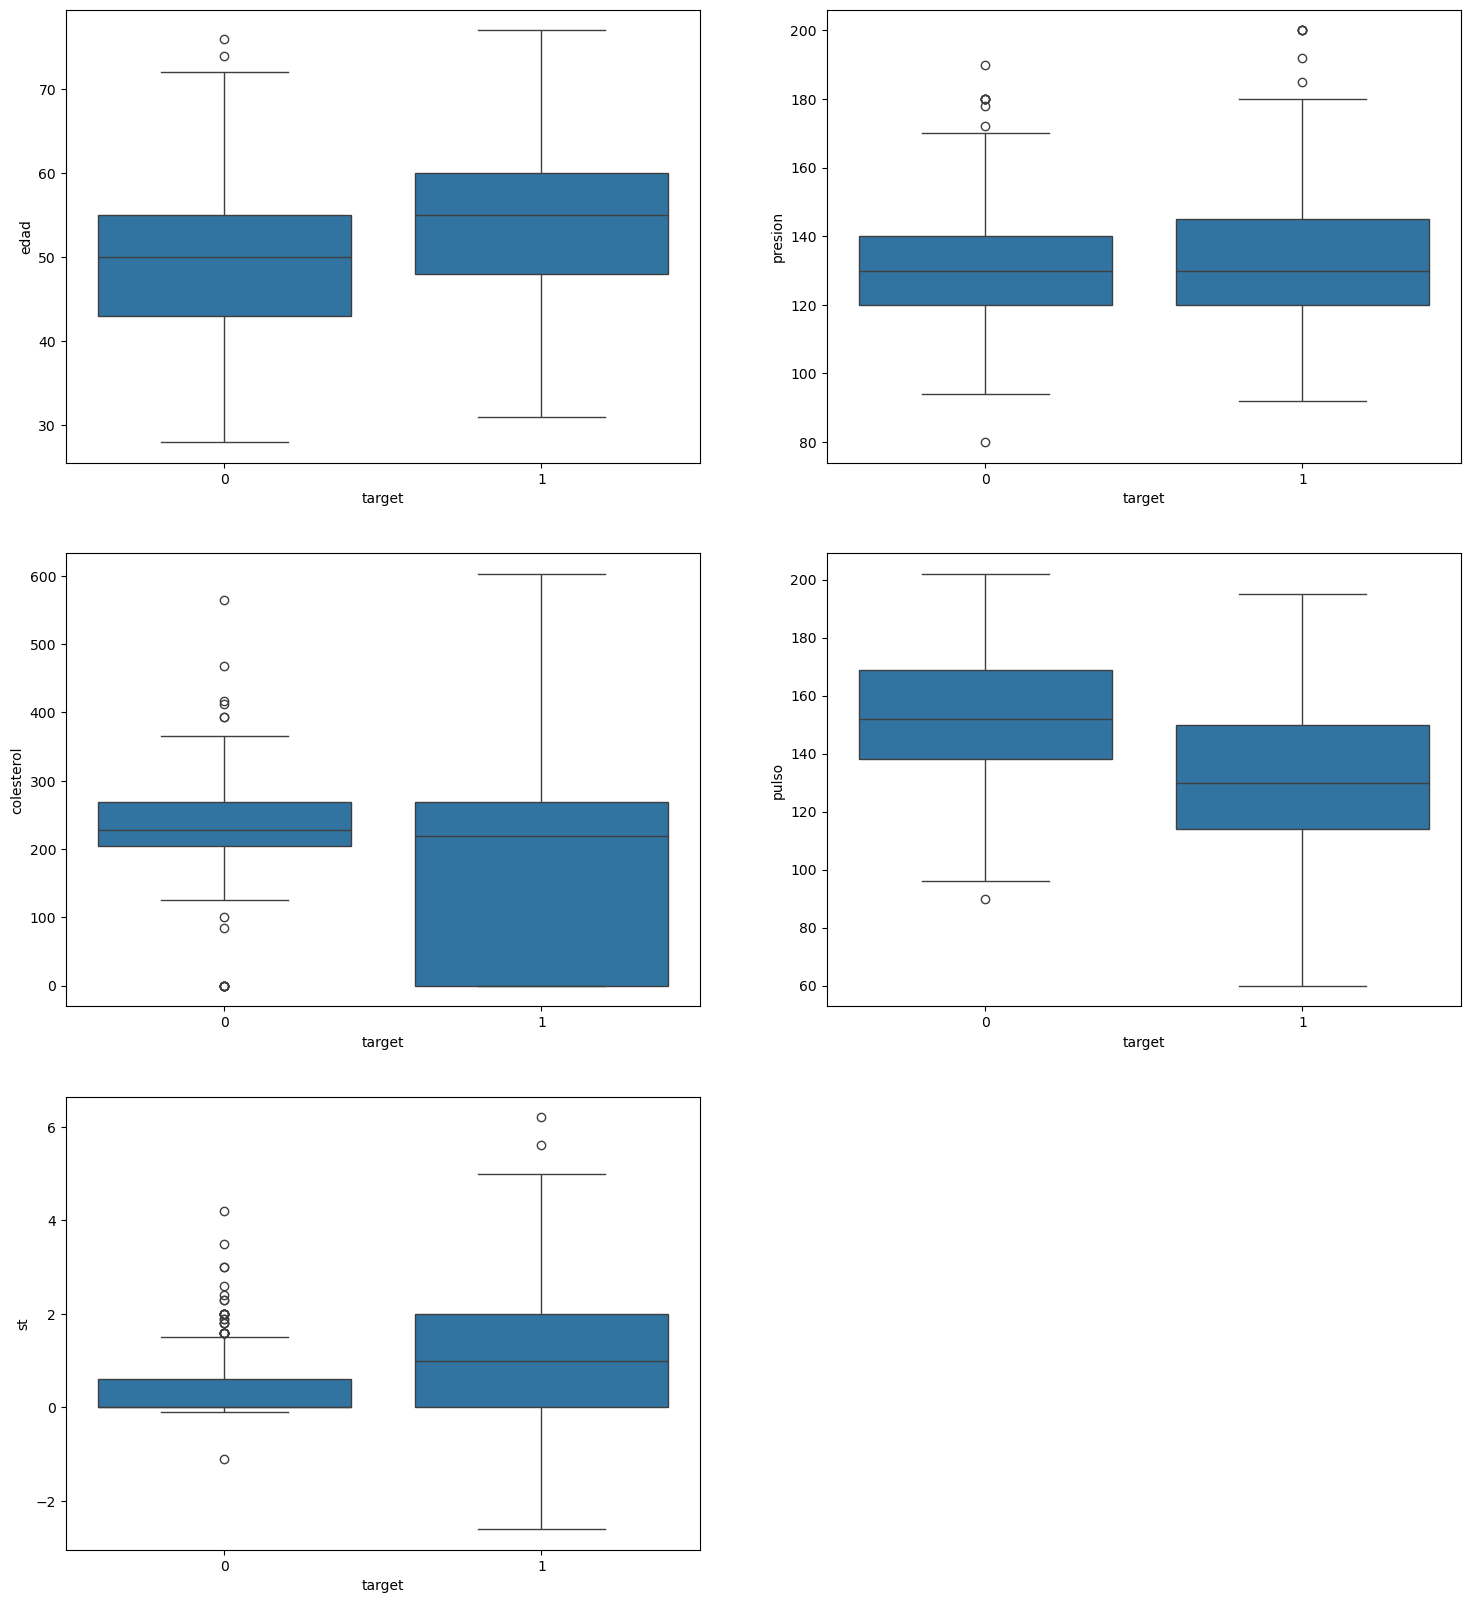

In [49]:
cols = ['edad','presion','colesterol','pulso','st']
i=1
plt.figure(figsize=(18,20))
for col in cols:
    plt.subplot(3,2,i)
    sns.boxplot(x='target',y=col,data=data)
    i += 1

Vamos a verificar los valores para las variables colesterol y st que pareciese tienen valores alejados de la media.

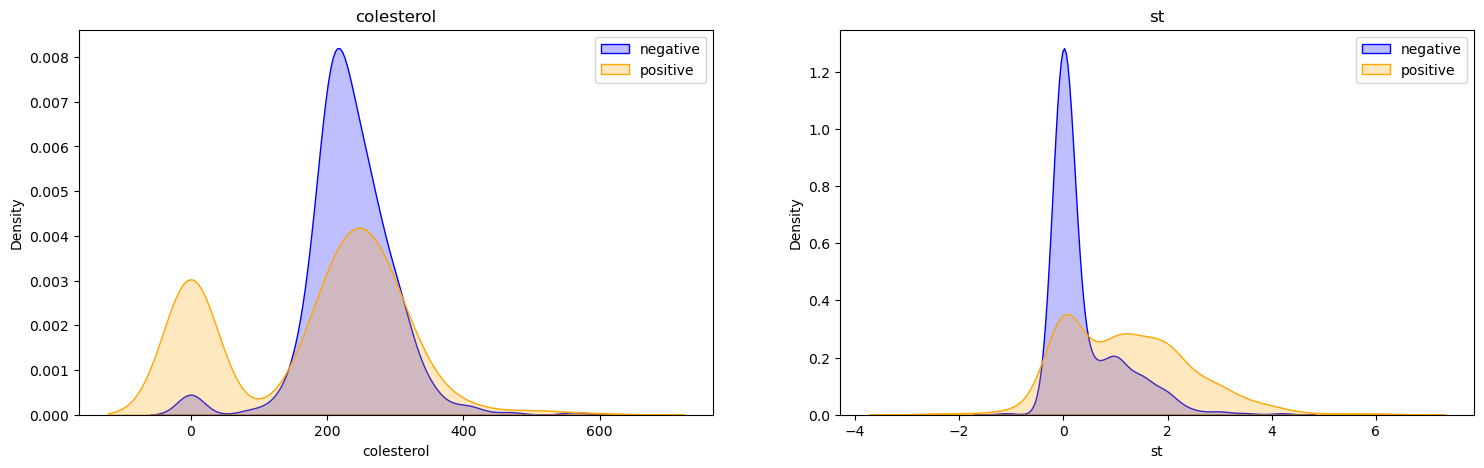

In [50]:
cols = ['colesterol','st']
i=1
plt.figure(figsize=(18,5))
for col in cols:
    plt.subplot(1,2,i)
    sns.kdeplot(data[data['target']=='0'][col],shade=True,color='blue')
    sns.kdeplot(data[data['target']=='1'][col],shade=True,color='orange')
    plt.legend(['negative','positive'])
    plt.title(col)
    i += 1

No consideramos que haya valores salidos demasiado de lo normal:
- En el st tenemos colas largas sin ser anómalas
- En el colesterol tenemos datos marcadamente bimodales, por lo que no se tratan de anomalías.

In [53]:
upper_bounds={}
lower_bounds={}
cols = ['edad','presion','colesterol','pulso','st']
for col in cols:
    values=data[col]
    upper_bounds[col]=values.mean()+4*values.std()
    lower_bounds[col]=values.mean()-4*values.std()

In [ ]:
for col in cols:
    values=data[col]
    if(data[values>upper_bounds[col]][col].count() > 0):
        print(data[values>upper_bounds[col]][col])
    if(data[values<lower_bounds[col]][col].count() > 0):
        print(data[values<lower_bounds[col]][col])

91     6.2
123    5.6
Name: st, dtype: float64
